**Practica_2_Parte_2:**

presentado por: Karly Tarazona, Luis Montoya

**procedimiento**

1. Exploración y descripción de la base de datos

Realice una exploración general de la base de datos proporcionada. Identifique y describa:

• Número total de registros y sujetos. 

• Tipos de arritmias o clases disponibles. 

• Número de sujetos o registros pertenecientes a cada grupo. 

• Número de canales disponibles y sus correspondientes derivaciones. 

• Frecuencia de muestreo y duración de los registros. 

Presente esta información mediante tablas y, cuando sea pertinente, gráficos que permitan visualizar 
la distribución de los datos entre las diferentes clases

Procesando 12049 archivos CSV...

1. EXPLORACIÓN Y DESCRIPCIÓN DE LA BASE DE DATOS
• Número total de registros y sujetos: 10646
• Tipos de arritmias o clases disponibles: ['ST', 'AFIB', 'AF', 'SVT', 'SA', 'SB', 'SR', 'AT', 'AVNRT', 'SAAWR', 'AVRT']
• Número de canales disponibles: 12
• Derivaciones correspondientes: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
• Frecuencia de muestreo (Fs): 500 Hz
• Duración promedio de los registros: 10.00 segundos

--- Tabla: Número de sujetos por cada grupo ---


,Tipo de Arritmia / Clase,Número de Sujetos / Registros
0,SB,3889
1,SR,1826
2,AFIB,1780
3,ST,1568
4,SVT,587
5,AF,445
6,SA,399
7,AT,121
8,AVNRT,16
9,AVRT,8


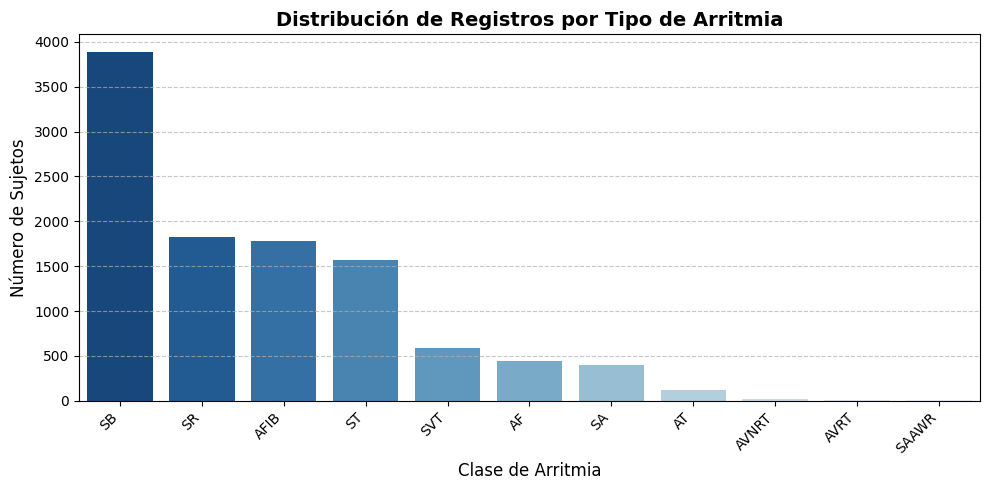

In [3]:
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración de rutas y parámetros
RUTA_CARPETA = r"ECGDataDenoised"
DIAGNOSTICS_PATH = r"Diagnostics.xlsx"
FS = 500  # Frecuencia de muestreo (Hz)
DERIVACIONES = [
    'I',
    'II',
    'III',
    'aVR',
    'aVL',
    'aVF',
    'V1',
    'V2',
    'V3',
    'V4',
    'V5',
    'V6',
]

# 1. Cargar el Excel e indexar por 'FileName' para búsquedas instantáneas
diagnostics = pd.read_excel(DIAGNOSTICS_PATH).set_index('FileName')

# 2. Buscar archivos CSV
archivos_csv = glob.glob(os.path.join(RUTA_CARPETA, '*.csv'))
print(f'Procesando {len(archivos_csv)} archivos CSV...')

registros_exploracion = []

for archivo in archivos_csv:
  filename_stem = Path(archivo).stem

  # Búsqueda en el índice del Excel
  if filename_stem in diagnostics.index:
    arritmia = diagnostics.loc[filename_stem, 'Rhythm']

    # Si por alguna razón hay duplicados en el Excel, tomar el primero
    if isinstance(arritmia, pd.Series):
      arritmia = arritmia.iloc[0]

    # Leer CSV indicando header=None para no interpretar la 1ra muestra como encabezado
    df = pd.read_csv(archivo, header=None)
    num_muestras = len(df)
    duracion_seg = num_muestras / FS

    registros_exploracion.append({
        'Archivo': filename_stem,
        'Arritmia': arritmia,
        'Muestras': num_muestras,
        'Duracion_s': duracion_seg,
        'Canales': len(df.columns),
    })

# Crear DataFrame consolidado
df_exploracion = pd.DataFrame(registros_exploracion)


# impresiones y visualización 

print('\n==================================================')
print('1. EXPLORACIÓN Y DESCRIPCIÓN DE LA BASE DE DATOS')
print('==================================================')

# Total de registros
total_registros = len(df_exploracion)
print(f'• Número total de registros y sujetos: {total_registros}')

# Tipos de arritmias
tipos_arritmias = df_exploracion['Arritmia'].unique().tolist()
print(f'• Tipos de arritmias o clases disponibles: {tipos_arritmias}')

# Canales y derivaciones
print(f'• Número de canales disponibles: {len(DERIVACIONES)}')
print(f'• Derivaciones correspondientes: {DERIVACIONES}')

# Fs y duración promedio
print(f'• Frecuencia de muestreo (Fs): {FS} Hz')
print(
    '• Duración promedio de los registros:'
    f" {df_exploracion['Duracion_s'].mean():.2f} segundos\n"
)

# Conteo por grupos
conteo_grupos = df_exploracion['Arritmia'].value_counts().reset_index()
conteo_grupos.columns = [
    'Tipo de Arritmia / Clase',
    'Número de Sujetos / Registros',
]

print('--- Tabla: Número de sujetos por cada grupo ---')
display(conteo_grupos)

# Gráfico de distribución
plt.figure(figsize=(10, 5))
sns.barplot(
    data=conteo_grupos,
    x='Tipo de Arritmia / Clase',
    y='Número de Sujetos / Registros',
    hue='Tipo de Arritmia / Clase',
    legend=False,
    palette='Blues_r',
)
plt.title(
    'Distribución de Registros por Tipo de Arritmia',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Clase de Arritmia', fontsize=12)
plt.ylabel('Número de Sujetos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Este código permite cargar todos los archivos  de manera eficiente. Se tiene en cuenta los datos de muestreo que se tuvo en las mediciones y adicionalmente se muestra en tabla y graficamente la distribución de los sujetos según la arritmia que tienen.

2. Visualización y caracterización de las señales
Seleccione dos registros de dos tipos de arritmia. Realice una breve consulta de esas dos arritmias
y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud, 
frecuencia cardíaca y regularidad de los latidos.

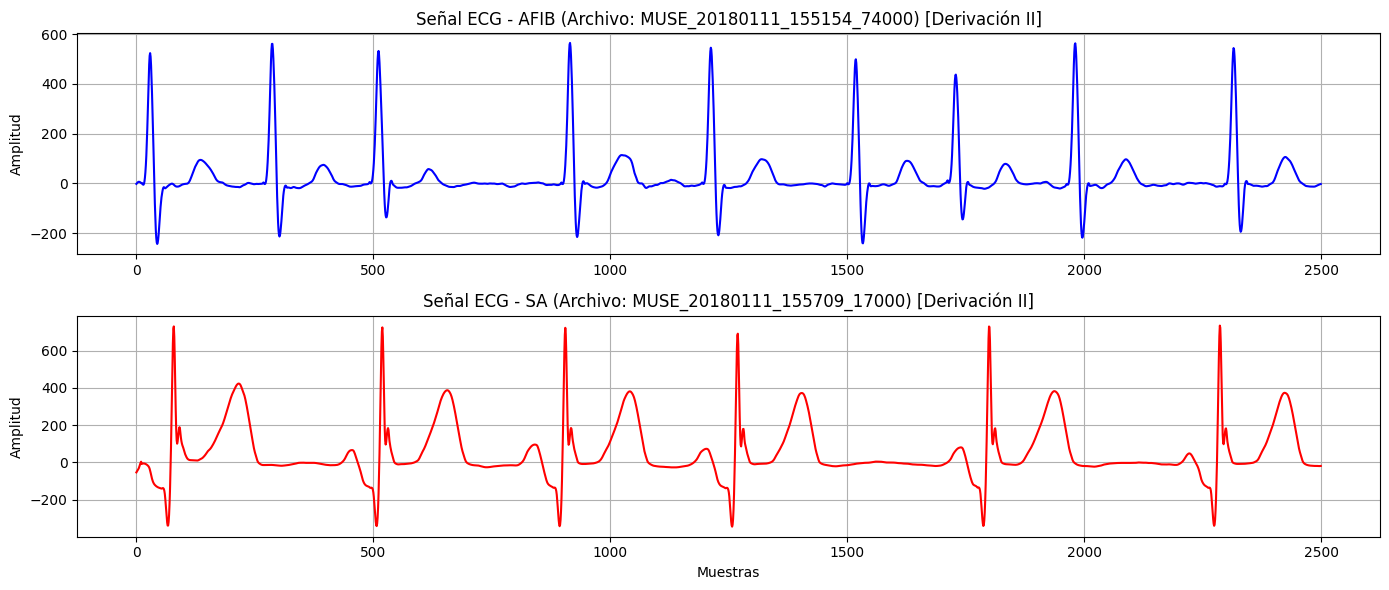

In [4]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# 1. Agrupar y almacenar archivos por tipo de arritmia
arritmias_dict = (
    df_exploracion.groupby('Arritmia')['Archivo'].apply(list).to_dict()
)

# Ahora las listas son:
# arritmias_dict['AFIB'] -> Fibrilación Auricular
# arritmias_dict['SA']   -> Arritmia Sinusal


# 2. Función de visualización comparativa entre dos clases
def visualizar_dos_arritmias_por_clase(
    df_exploracion,
    arritmia_1='AFIB',
    arritmia_2='SA',  
    RUTA_CARPETA='ECGDataDenoised',
):
  # Filtrar los registros pertenecientes a cada arritmia
  reg1 = df_exploracion[df_exploracion['Arritmia'] == arritmia_1]
  reg2 = df_exploracion[df_exploracion['Arritmia'] == arritmia_2]

  if reg1.empty or reg2.empty:
    print(
        f'No se encontraron registros para {arritmia_1} o la clase'
        f' {arritmia_2}.'
    )
    return

  # Tomar un archivo representativo de cada clase
  nombre_1 = reg1.iloc[0]['Archivo']
  nombre_2 = reg2.iloc[0]['Archivo']

  archivo_1 = os.path.join(RUTA_CARPETA, f'{nombre_1}.csv')
  archivo_2 = os.path.join(RUTA_CARPETA, f'{nombre_2}.csv')

  # Leer los archivos
  df1 = pd.read_csv(archivo_1, header=None)
  df2 = pd.read_csv(archivo_2, header=None)

  if 'DERIVACIONES' in globals() and len(df1.columns) == len(DERIVACIONES):
    df1.columns = DERIVACIONES
    df2.columns = DERIVACIONES

  canal = 'II' if 'II' in df1.columns else df1.columns[1]

  plt.figure(figsize=(14, 6))

  # Visualización AFIB
  plt.subplot(2, 1, 1)
  plt.plot(df1[canal].values[:2500], color='blue')
  plt.title(
      f'Señal ECG - {arritmia_1} (Archivo: {nombre_1}) [Derivación {canal}]'
  )
  plt.ylabel('Amplitud')
  plt.grid(True)

  # Visualización SA (Arritmia Sinusal)
  plt.subplot(2, 1, 2)
  plt.plot(df2[canal].values[:2500], color='red')
  plt.title(
      f'Señal ECG - {arritmia_2} (Archivo: {nombre_2}) [Derivación {canal}]'
  )
  plt.xlabel('Muestras')
  plt.ylabel('Amplitud')
  plt.grid(True)

  plt.tight_layout()
  plt.show()


# Llamada a la función comparando AFIB y SA (Arritmia Sinusal)
visualizar_dos_arritmias_por_clase(
    df_exploracion, arritmia_1='AFIB', arritmia_2='SA'
)

- **Arritmia_1:** (AFib) fibrilación auricular es un ritmo cardíaco irregular y a menudo acelerado que ocurre cuando las cavidades superiores del corazón laten de forma caótica, en un trazado con AFib los picos se presentan de forma completamente desorganizada y a tiempos desiguales. Además, la línea base entre cada latido deja de ser plana y se muestra temblorosa debido a la vibración caótica de las aurículas, tambien se presenta ausencia de ondas P.
La señal eléctrica que viaja hacia el ventrículo derecho se retrasa. Esto hace que los ventrículos se despolaricen de forma asincrónica, ensanchando drásticamente el complejo QRS, las aurículas están latiendo exactamente al doble de velocidad que los ventrículos y la señal tiene una amplitud enorme, con oscilaciones que van desde los +300 mV hasta los -400 mV viendose que toda la fuerza eléctrica está dominada por los ventrículos.

- **Arritmia_2:** (SA) La arritmia sinusal es una fluctuación que se da en la frecuencia de los latidos. Una de las causas más común es por la respiración. Como menciona Mitchell (s. f.) Se le llama arritmia sinusal respiratoria  al aumento de la frecuencia cardíaca durante la inspiración. Es importante tener en cuenta que no solo se trata de esta fase de la respiración sino que en la arritmia SR la frecuencia cardíaca oscila de manera coordinada con las fases de la respiración. Con la inspiración los intervalos entre latidos se acortan debido a una menor presión intratorácica y un intento del organismo de compensar el mayor retorno venoso que se da. Por otro lado, con la expiración y el aumento de presión intratorácica se reduce la frecuencia.
Como características la arritmia sinusal muestra un intervalo QRS más estrecho y un intérvalo PP o RR variable.


En los gráficos se pueden observar los aspectos descritos en la teoría de estas arritmias:

- Para la AFib se puede observar que la onda P en la mayoría de casos no existe y cuando lo hace es solo una perturbación pequeña a la vez que entre latidos completos no se tiene una línea recta por la incapacidad del corazón de volver a estabilizar si polaridad. Se tiene un complejo QRS más ancho con el punto R variando en su amplitud.

- Para la SA se observa que la frecuencia de los latidos no es constante y se generan unos intérvalos en los que el corazón late con diferente frecuencia. En este caso no se alcanza a observar el punto S de la gráfica o el final de la despolarización ventricular.


3. Análisis estadístico entre arritmias
Calcule y compare mediante un análisis descriptivo (box plots, diagramas de densidad, etc.) las 
siguientes características descriptivas: media, desviación estándar, valor máximo, valor mínimo, 
frecuencia cardíaca y el valor RMS. 
Formule una hipótesis nula y una hipótesis alternativa con las arritmias escogidas anteriormente.
Antes de aplicar una prueba estadística paramétrica, compruebe los supuestos necesarios para realizar 
una prueba t de Student. Si los supuestos se cumplen, realice la prueba t de Student para muestras 
independientes con el fin de determinar si existen diferencias estadísticamente significativas entre los 
grupos de arritmias. Si no se cumple el supuesto de normalidad o las condiciones necesarias para 
utilizar la prueba t, realice un análisis no paramétrico mediante la prueba U de Mann-Whitney, 
apropiada para comparar dos grupos independientes.


In [5]:
import os
import numpy as np
import pandas as pd
import scipy.signal as signal
# Configuración de frecuencia de muestreo 
FS = 500 

def calcular_metricas_ecg(df_signal, canal='II', fs=FS):
    """Calcula características estadísticas y Frecuencia Cardíaca para una señal ECG."""
    # Seleccionar canal (Derivación II o la primera disponible)
    if canal in df_signal.columns:
        x = df_signal[canal].values
    else:
        x = df_signal.iloc[:, 1 if df_signal.shape[1] > 1 else 0].values

    # Remover NaN si existen
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return None

    # Métricas descriptivas básicas
    media = np.mean(x)
    std = np.std(x)
    val_max = np.max(x)
    val_min = np.min(x)
    rms = np.sqrt(np.mean(x**2))

    # Estimación de Frecuencia Cardíaca (HR) mediante picos R
    # Distancia mínima entre picos: 0.4s (150 bpm max) -> 0.4 * fs muestras
    min_dist = int(0.4 * fs)
    # Prominencia adaptativa para detectar picos R
    prominence = 0.5 * std if std > 0 else None
    
    picos, _ = signal.find_peaks(x, distance=min_dist, prominence=prominence)

    if len(picos) > 1:
        intervalos_rr_seg = np.diff(picos) / fs
        hr_bpm = 60.0 / np.mean(intervalos_rr_seg)
    else:
        hr_bpm = np.nan  # Si no detecta suficientes picos

    return {
        'Media': media,
        'Desviacion_Estandar': std,
        'Maximo': val_max,
        'Minimo': val_min,
        'RMS': rms,
        'Frecuencia_Cardiaca': hr_bpm
    }


def extraer_caracteristicas_dataset(arritmias_dict, ruta_carpeta='ECGDataDenoised', derivaciones=None):
    """Recorre todos los archivos de cada arritmia y extrae las métricas."""
    registros = []

    for arritmia, lista_archivos in arritmias_dict.items():
        if arritmia not in ['AFIB', 'SA']:
            continue
            
        for nombre_archivo in lista_archivos:
            archivo_path = os.path.join(ruta_carpeta, f"{nombre_archivo}.csv")
            if not os.path.exists(archivo_path):
                continue
                
            df_temp = pd.read_csv(archivo_path, header=None)
            if derivaciones and len(df_temp.columns) == len(derivaciones):
                df_temp.columns = derivaciones

            canal = 'II' if 'II' in df_temp.columns else df_temp.columns[1]
            metricas = calcular_metricas_ecg(df_temp, canal=canal)

            if metricas:
                metricas['Archivo'] = nombre_archivo
                metricas['Arritmia'] = arritmia
                registros.append(metricas)

    return pd.DataFrame(registros)


# 1. Extracción de métricas de todos los archivos
df_metricas = extraer_caracteristicas_dataset(
    arritmias_dict, 
    ruta_carpeta='ECGDataDenoised', 
    derivaciones=DERIVACIONES if 'DERIVACIONES' in globals() else None
)

# 2. Generación de la tabla descriptiva resumida (Media ± Desviación Estándar por Arritmia)
variables = ['Media', 'Desviacion_Estandar', 'Maximo', 'Minimo', 'RMS', 'Frecuencia_Cardiaca']

tabla_resumen = df_metricas.groupby('Arritmia')[variables].agg(['mean', 'std']).T
print("=== TABLA DESCRIPTIVA DE CARACTERÍSTICAS (Media ± Std) ===")
display(tabla_resumen)

=== TABLA DESCRIPTIVA DE CARACTERÍSTICAS (Media ± Std) ===


Arritmia                        AFIB           SA
Media               mean   24.286408    45.062402
                    std    23.499411    22.889160
Desviacion_Estandar mean  129.011410   163.108845
                    std    63.818470    59.109715
Maximo              mean  795.320708  1129.308847
                    std   430.040959   447.770389
Minimo              mean -287.312712  -254.432897
                    std   369.136649   191.443665
RMS                 mean  132.401603   169.803032
                    std    65.790895    61.801460
Frecuencia_Cardiaca mean   89.377047    74.237794
                    std    13.510568    10.369340

En la tabla se tienen las características descriptivas considerando todos los sujetos en la base de datos que tienen la arritmia elegida.
Los datos de Media, Desviación_Estándar, Máximo, Mínimo y RMS están dados en micro voltios (uV). Mientras que la Frecuencia_Cardiaca está en latidos por minuto.

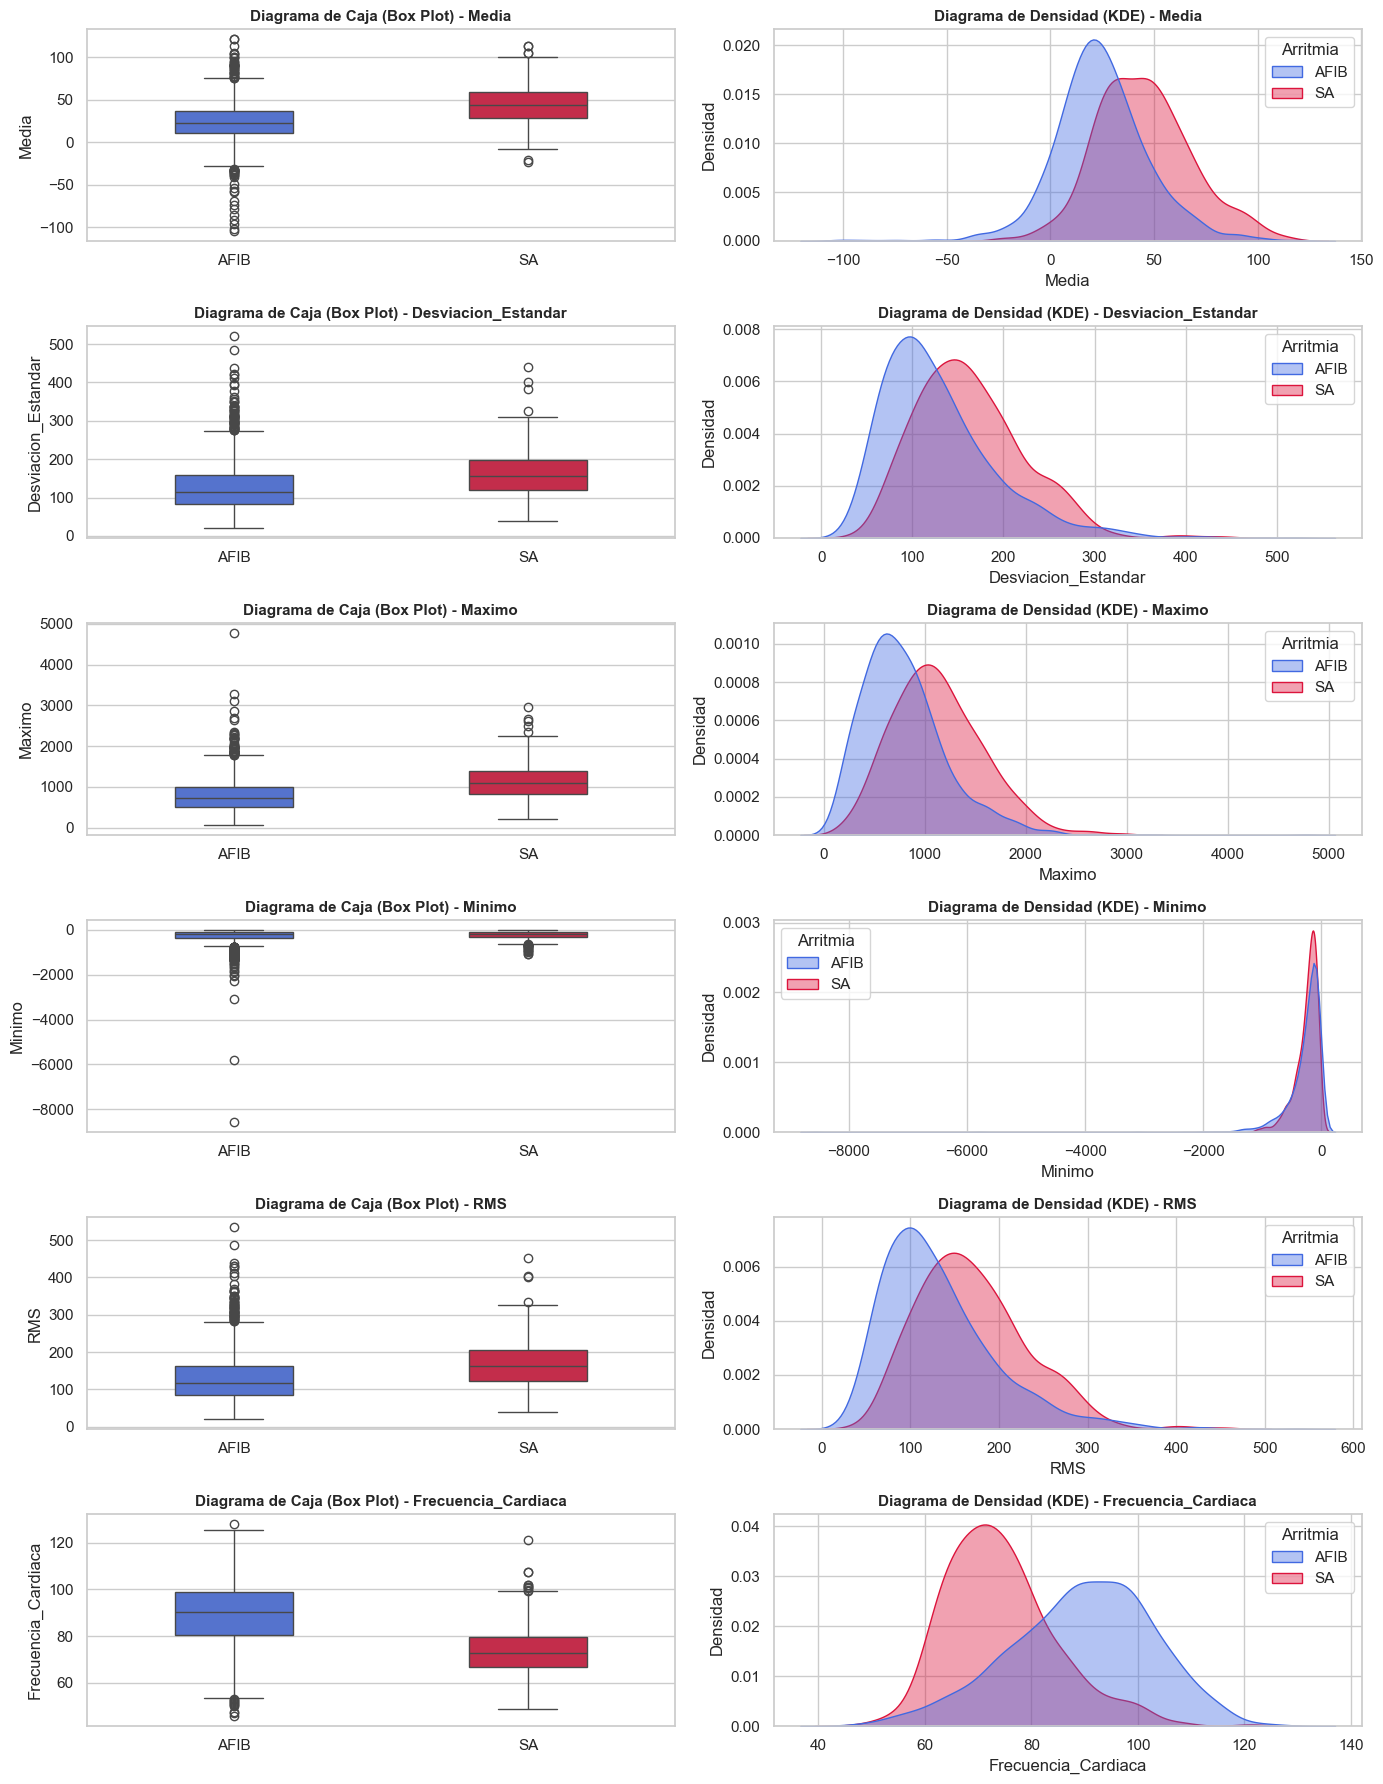

In [6]:
sns.set_theme(style="whitegrid")
colores = {'AFIB': 'royalblue', 'SA': 'crimson'}

fig, axes = plt.subplots(len(variables), 2, figsize=(14, 3 * len(variables)))

for i, var in enumerate(variables):
    # Box Plot con hue y legend agregados para evitar advertencias
    sns.boxplot(
        data=df_metricas, 
        x='Arritmia', 
        y=var, 
        hue='Arritmia',
        legend=False,
        ax=axes[i, 0], 
        palette=colores, 
        width=0.4
    )
    axes[i, 0].set_title(f'Diagrama de Caja (Box Plot) - {var}', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel(var)

    # Diagrama de Densidad (KDE)
    sns.kdeplot(
        data=df_metricas, x=var, hue='Arritmia', ax=axes[i, 1], 
        palette=colores, fill=True, common_norm=False, alpha=0.4
    )
    axes[i, 1].set_title(f'Diagrama de Densidad (KDE) - {var}', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel(var)
    axes[i, 1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

- **Media:** tanto en el Boxplot como el diagrama de densidad muestran que el promedio de la media de cada sujeto con SA es mayor que con AFIB. En el diagrama de densidad se observa para SA un comportamiento como meseta que indica una densidad similar para distintos valores de medias individuales. Finalmente en el Boxplot de AFIB se tienen más outliers que en SA, un aspecto que tiene sentido según la naturaleza más caótica en el ECG de las personas con esta arritmia.

- **Desviación estándar:** en el diagrama de densidad se observa una mayor desviación para SA (centrada alrededor de 150) que para AFIB (centrada alrededor de ). Esto indica que en promedio la arritmia sinusal tiene mayor amplitud de onda que la fibrilación auricular. A pesar de esto, ambas gráficas se superponen en una gran área (zona de color morado). Esto indica que la Desviación Estándar no es una métrica que permita discriminar entre una arritmia u otra.
Adicional a esto en el boxplot se observa nuevamente una mayor cantidad de outliers para la fibrilación auricular.

- **Máximo:** por un lado, con el diagrama de densidad se puede ver que la media del valor máximo de amplitu de las señales para arritmia sinusal es mayor que para la fibrilación ventricular, pero debe considerarse que una gran cantidad de outliers en la fibrilación auricular evidencia las amplitudes más "caóticas" que la caracterizan. Esto en conjunto con la gran superposición que se observa para ambas arritmias indica que el valor máximo tampoco es un dato que permita hacer una diferenciación.

- **Mínimo:** en el boxplot sucede algo similar entre el estadístico del mínimo y el máximo, ya que se tienen muchos outliers para ambas arritmias pero que en el caso de la AFIB son mayor cantidad y toman valores muy extremos. Tampoco se considera un estadístico que permita una diferenciación ya que en casos donde hay tantas variaciones que suceden en el ciclo cardíaco y tanto el mínimo como el máximo dependen de un único valor en la señal completa, existirá esta gran cantidad de outliers.

- **RMS:** el análisis de los gráficos muestra una potencia eléctrica promedio mayor para las señales de arritmia sinusal (169.803032) que para fibrilación auricular (132.401603). Esta variación se puede dar por la pérdida de la onda P en la AFIB, lo cual se traduce en una pérdida de potencia. Pérdida que no se da en la SA.
A pesar de esto, nuevamente hay una gran superposición para ambas arritmias limitando el uso del valor RMS para discriminar.

- **Frecuencia Cardíaca:** la AFIB tiene una mayor frecuencia cardíaca en promedio que la SA. Esto puede ser por la característica de una frecuencia variable para la arritmia sinusal siendo más rapida por momentos pero luego con intervalos mayores de tiempo entre ciclos completos. Esto a lo largo de muchas muestras puede reducir la frecuencia cardíaca en el intervalo completo. 
La frecuencia cardíaca como característica de la señal del ECG si permite una diferenciación para los casos arritmia sinusal y fibrilación auricular ya que es la que menor superposición o solapamiento presenta (área morada en diagrama de densidad) y adicionalmente se tiene la menor cantidad de outliers.


3.1 Formule una hipótesis nula y una hipótesis alternativa con las arritmias escogidas anteriormente:

con los resultados anteriores se plantean las hipótesis, según la cual la frecuencia cardíaca promedio de los pacientes con AFIB es mayor que la de los pacientes con SA. Sin embargo, la diferencia observada visualmente no es suficiente por sí sola para afirmar que existe una diferencia estadísticamente significativa. Para sustentar formalmente la hipótesis, es necesario aplicar una prueba estadística de comparación de medias.

- **Hipotesis nula**: no existe una diferencia estadisticamente significativa en la frecuencia cardiaca promedio entre los pacientes con fibrilacion auricular y arritmia sinusal.

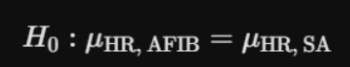

- **Hipotesis alternativa**: la frecuencia cardica promedio en los pacientes con fibrilacion auricular es significativamente mayor que en los pacientes con arritmia sinusal.

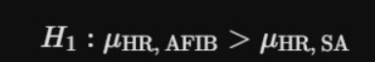

Se comprueban los supuestos necesarios para identificar si los datos son parametricos o no parametricos

- **Prueba de normalidad:**

- **Hipótesis Nula:** Los datos siguen una distribución normal. (La muestra no presenta desviaciones significativas respecto a la campana de Gauss).

- **Hipótesis Alternativa:** Los datos no siguen una distribución normal.


- **Prueba de homocedasticidad:**

- **Hipótesis Nula:** Las varianzas de los grupos son iguales (se cumple la homocedasticidad).

- **Hipótesis alternativa:** Las varianzas de los grupos no son iguales (existe heterocedasticidad).

con valor significativo de 0.05 normalmente usado.

In [7]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

afib = df_metricas[
    df_metricas['Arritmia'] == 'AFIB'
]['Frecuencia_Cardiaca'].dropna()

sa = df_metricas[
    df_metricas['Arritmia'] == 'SA'
]['Frecuencia_Cardiaca'].dropna()

def format_p_value(p):
    return "< 0.0001" if p < 0.0001 else f"{p:.4f}"

# NORMALIDAD - SHAPIRO-WILK
w_afib, p_afib = shapiro(afib)
w_sa, p_sa = shapiro(sa)

print("=== NORMALIDAD ===")
print(f"AFIB: W = {w_afib:.4f}, p = {format_p_value(p_afib)}")
print(f"SA:   W = {w_sa:.4f}, p = {format_p_value(p_sa)}")


# HOMOCEDASTICIDAD - LEVENE
w_levene, p_levene = levene(afib, sa)

print("\n=== HOMOCEDASTICIDAD ===")
print(f"Levene: W = {w_levene:.4f}, p = {format_p_value(p_levene)}")



=== NORMALIDAD ===
AFIB: W = 0.9914, p = < 0.0001
SA:   W = 0.9612, p = < 0.0001

=== HOMOCEDASTICIDAD ===
Levene: W = 41.8966, p = < 0.0001


Se rechaza H0 se concluye que los datos no son normales y las varianzas son significativamente diferentes. En ese caso, no se puede usar la t de Student clásica y se debe emplear una alternativa como la prueba  Mann-Whitney U que ordena todos los valores juntos y analiza si los valores de un grupo tienden a ocupar rangos más altos o más bajos que los del otro.

Como la dinámica de la Fibrilación Auricular (AFIB), se caracteriza por una actividad eléctrica auricular completamente caótica, descoordinada y de alta frecuencia, esto se traduce en una alta variabilidad ciclo a ciclo en la morfología y frecuencia de la señal ECG. En la AFIB, al no haber un marcapasos central y tener un caos eléctrico; los latidos pueden registrar saltos abruptos, latidos prematuros o rachas muy irregulares, lo que genera asimetrías severas, en su distribucion. Por su parte, la dinámica de la Arritmia Sinusal sigue un patrón cíclico, pero sesgado por la respiración, por lo que tampoco se distribuye como una gaussiana perfecta. A su vez al tener una variacion diferente entre ambas caracteristicas la homocedasticidad tampoco se cumple.

Se procede a usar Mann-Whitney U

In [10]:
# RESULTADO FINAL

estadistico, p = mannwhitneyu(afib, sa, alternative='greater')
prueba = "Mann-Whitney U"

print("\n=== PRUEBA ESTADÍSTICA ===")
print("Prueba utilizada:", prueba)
print(f"Estadístico = {estadistico:.4f}")
print(f"p-valor = {format_p_value(p)}")

if p < 0.05:
    print("Existe una diferencia estadísticamente significativa entre AFIB y SA.")
else:
    print("No existe una diferencia estadísticamente significativa entre AFIB y SA.")

resumen = df_metricas.groupby('Arritmia')['Frecuencia_Cardiaca'].agg(
    n='count',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)

print("=== RESUMEN DE FRECUENCIA CARDÍACA ===")
display(resumen)



=== PRUEBA ESTADÍSTICA ===
Prueba utilizada: Mann-Whitney U
Estadístico = 578757.5000
p-valor = < 0.0001
Existe una diferencia estadísticamente significativa entre AFIB y SA.
=== RESUMEN DE FRECUENCIA CARDÍACA ===


,n,Mediana,Minimo,Maximo
Arritmia,,,,
AFIB,1780,90.230735,45.662100,127.974854
SA,399,72.895958,48.712596,121.276596


Se evidencia de una separación poblacional profunda, ya que el valor p es menor al significativo de 0.05, esto confirma que los mecanismos electrofisiológicos que gobiernan la Fibrilación Auricular (AFIB) y la Arritmia Sinusal (SA) pertenecen a regímenes dinámicos totalmente incomunicados y estructuralmente distintos. ya que en la arritmia sinusal a pesar de existir fluctuaciones en la frecuencia cardíaca , el estímulo eléctrico sigue originándose de forma legítima en el nodo sinusal.Por el contrario, la Fibrilación Auricular (AFIB) se caracteriza por múltiples microcircuitos.Por otro lado, dado a que la mediana de la Fibrilación Auricular es notablemente superior se puede decir que esta es mayor que las presentadas en la arritmia sinusal. Rechazando el H0 planteado y aceptando por su parte el H1.

**Bibliografía**

- Mitchell, L. B. (s. f.). Generalidades sobre las arritmias. Manual MSD Versión para profesionales. https://www.msdmanuals.com/es/professional/trastornos-cardiovasculares/generalidades-sobre-la-conducci%C3%B3n-card%C3%ADaca/generalidades-sobre-las-arritmias

- Wasserstein, R. L., & Lazar, N. A. (2016). The ASA's statement on p-values: Context, process, and purpose. The American Statistician, 70(2), 129–133. https://doi.org/10.1080/00031305.2016.1154108

